In [1]:
import json
import pandas as pd
import numpy as np

data_path = '../preprocess/ALC_features_Functional_toy.json'

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_json(data_path, orient='index')
df.head()

,intoxicated,breath alcohol concentration,blood alcohol concentration,features
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses2069/0732069050_h_00.wav,na,0.00000,0.00000,{'F0semitoneFrom27.5Hz_sma3nz_amean': [24.8224...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses3045/5433045004_h_00.wav,a,0.00047,0.00047,{'F0semitoneFrom27.5Hz_sma3nz_amean': [33.2336...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses1097/0961097007_h_00.wav,a,0.00064,0.00068,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.1055...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses1006/0061006026_h_00.wav,a,0.00081,0.00073,{'F0semitoneFrom27.5Hz_sma3nz_amean': [33.9375...
/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/data/ALC/ses4066/5864066025_h_00.wav,na,0.00000,0.00000,{'F0semitoneFrom27.5Hz_sma3nz_amean': [25.2502...


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

In [5]:
train['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [21.29319190979004],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [0.14720295369625],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [19.489044189453125],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [21.178083419799805],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [22.671470642089844],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [3.182426452636718],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [232.42596435546875],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [528.190673828125],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [152.46133422851562],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [273.87591552734375],
 'loudness_sma3_amean': [0.173180937767028],
 'loudness_sma3_stddevNorm': [0.862767338752746],
 'loudness_sma3_percentile20.0': [0.038186982274055],
 'loudness_sma3_percentile50.0': [0.135757327079772],
 'loudness_sma3_percentile80.0': [0.28392481803894004],
 'loudness_sma3_pctlrange0-2': [0.24573783576488403],
 'loudne

# Majority Baseline 
(Just one dummy feature)

In [6]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [7]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 121 data samples.
Each data sample is a vector of 1 dimensions.


In [8]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [9]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [10]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [11]:
y_train[:2]

[0, 0]

In [12]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [13]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

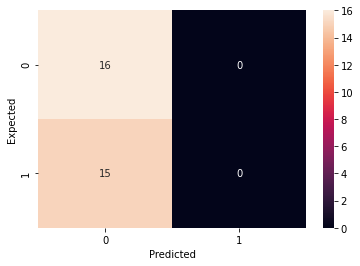

In [14]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [15]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[21.29319190979004,
 0.14720295369625,
 19.489044189453125,
 21.178083419799805,
 22.671470642089844,
 3.182426452636718,
 232.42596435546875,
 528.190673828125,
 152.46133422851562,
 273.87591552734375,
 0.173180937767028,
 0.862767338752746,
 0.038186982274055,
 0.135757327079772,
 0.28392481803894004,
 0.24573783576488403,
 4.36713171005249,
 3.373101949691772,
 3.195494890213012,
 2.193646430969238,
 0.081855095922946,
 1.315399169921875,
 23.692832946777344,
 0.6792383790016171,
 12.575139045715332,
 0.8422548174858091,
 11.862066268920898,
 1.121647000312805,
 5.848635196685791,
 1.75156557559967,
 0.026467377319931002,
 1.138892769813537,
 1.576244831085205,
 0.8744199275970451,
 2.653019428253174,
 1.461140513420105,
 2.371616125106811,
 5.039660453796387,
 30.38582420349121,
 0.409201443195343,
 512.471923828125,
 0.318497627973556,
 1302.3035888671875,
 0.150735989212989,
 -120.05657958984375,
 -0.7486030459403991,
 1543.6717529296875,
 0.185538440942764,
 994.8231811523438,


In [16]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 121 data samples.
Each data sample is a vector of 88 dimensions.


In [17]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [18]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [19]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [20]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

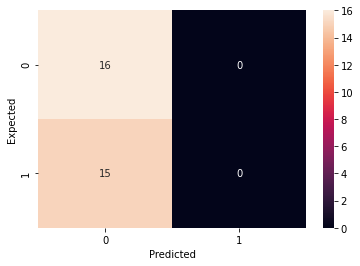

In [21]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [23]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.6129032258064516

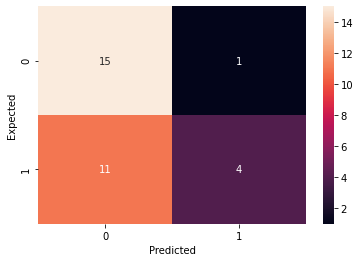

In [24]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [25]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.45161290322580644

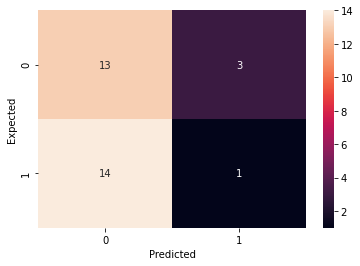

In [26]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [27]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/usr/lib64/python3.10/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.5483870967741935

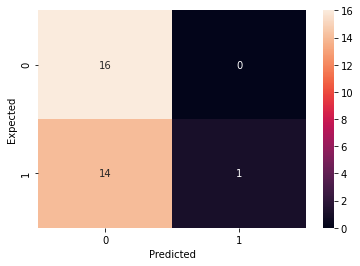

In [28]:
evaluate_classifier(svm_classifier, X_test, y_test)

# Majority Baseline for the Levels (Regression Task)

In [44]:
from sklearn import linear_model

In [64]:
linmodel = linear_model.LinearRegression(fit_intercept=True)

In [65]:
def features_to_vec(feature_dict, i=0):
    out_vector = [list(feature_dict.values())[i][0]] #first of i-th feature only
    return out_vector

X_train = train['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [66]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

0.0001215190831043594 0.00029489029531959437


In [67]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: -0.05


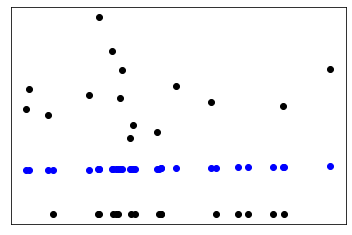

In [68]:
import matplotlib.pyplot as plt
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [87]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur

7 0.041069044023510304
Mean squared error: 0.00
Coefficient of determination: 0.04


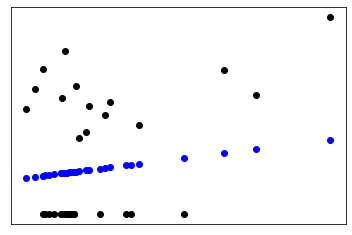

In [97]:
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

## On only those who have non-0 alc level
### In the breath
Feature 38 seems to be correlated with the alcohol level in blood

In [98]:
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

38 0.2827735406914932
Mean squared error: 0.00
Coefficient of determination: 0.28


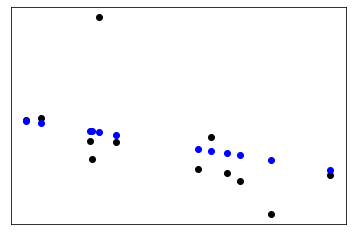

In [99]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### In the blood
Also feature 38, but less correlated

38 0.051919032584812896
Mean squared error: 0.00
Coefficient of determination: 0.05


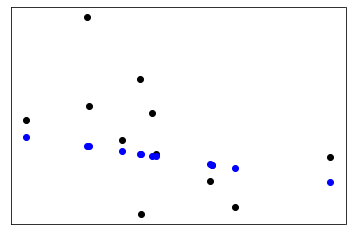

In [100]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = test['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

In [103]:
#What is this feature 38?
list(df['features'][0].keys())[38]

'logRelF0-H1-A3_sma3nz_amean'

## Multiple Linear Regression

### On all features and all data

In [31]:
X_train = train['features'].apply(features_to_vec).tolist() 
X_test = test['features'].apply(features_to_vec).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [32]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-7.766823947937333e-05 -0.007224870380923101


In [33]:
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
y_pred = linmodel.predict(X_test)

In [37]:
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: -77.47


In [38]:
import matplotlib.pyplot as plt

Note: Visualization problematic. Only one feature (dimension) can be selected for 0x while we have many (88)

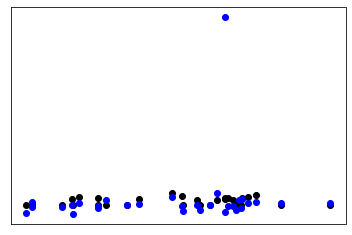

In [42]:
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

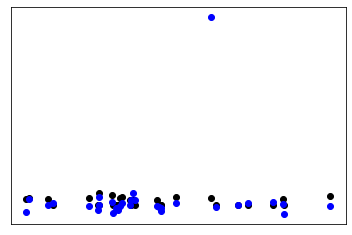

In [43]:
# Plot outputs
#based on the first features
x_test_0 = [x[1] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative blood alcohol level on all features

0 -17.31377127125525
Mean squared error: 0.00
Coefficient of determination: -17.31


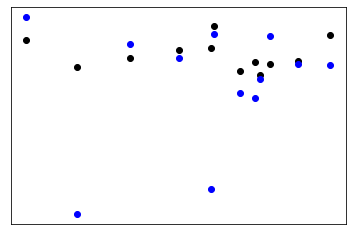

In [109]:
#NB: there's randomness here
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['blood alcohol concentration']
    y_test = test['blood alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on all features

0 -18.876233719863606
Mean squared error: 0.00
Coefficient of determination: -18.88


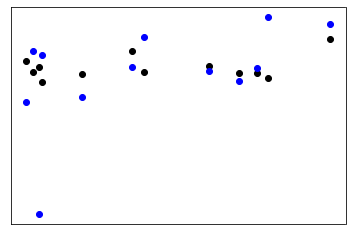

In [111]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict, i=0):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

#Find the feature that produces the best results (the best r2_score)
r2_score_max = -100
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative blood alcohol level on values of feature 38

Mean squared error: 0.00
Coefficient of determination: -0.03


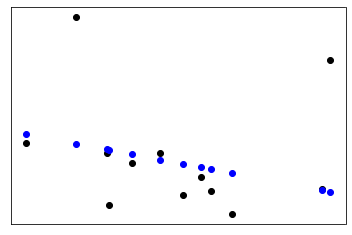

In [113]:
df = pd.read_json(data_path, orient='index')
df = df[df['blood alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['blood alcohol concentration']
y_test = test['blood alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

### On only non-negative breath alcohol level on values of feature 38

Mean squared error: 0.00
Coefficient of determination: 0.17


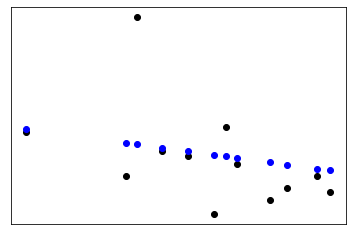

In [112]:
df = pd.read_json(data_path, orient='index')
df = df[df['breath alcohol concentration'] > 0]
train, test = train_test_split(df, test_size=0.2)


def features_to_vec(feature_dict):
    out_vector = []
    feature = list(feature_dict.values())[38]
    for subfeature in feature:
        out_vector.append(subfeature)
    return out_vector


linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
x_test_0 = [x[0] for x in X_test]
plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()